# Weather and Airport Congestion

This notebook examines the NOAA weather and ASPM airport conditions matched to each flight. It focuses on descriptive relationships with `DepDel15` and `ArrDel15`.

The matched records come from before scheduled departure. The charts show association, not proof that weather or congestion caused a delay.

In [1]:
from pathlib import Path
import sys

EDA_DIR = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd() / "eda"
if str(EDA_DIR) not in sys.path:
    sys.path.insert(0, str(EDA_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from config import AIRPORT, FIGURE_DPI, RANDOM_STATE, SCATTER_SAMPLE_SIZE, TOP_CATEGORIES, YEAR
from eda_utils import (
    TARGET_COLUMNS,
    WEATHER_FLAGS,
    add_eda_columns,
    category_rate,
    load_merged,
    safe_sample,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = FIGURE_DPI
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

df = add_eda_columns(load_merged(AIRPORT, YEAR))
print(f"Loaded {AIRPORT}_{YEAR}: {len(df):,} flights and {df.shape[1]:,} columns after EDA helpers.")

Loaded JFK_2019: 124,759 flights and 70 columns after EDA helpers.


## Weather distributions

These plots show the range and shape of the main continuous weather measurements. Unusual spikes or limits may reflect normal reporting practices as well as real weather conditions.

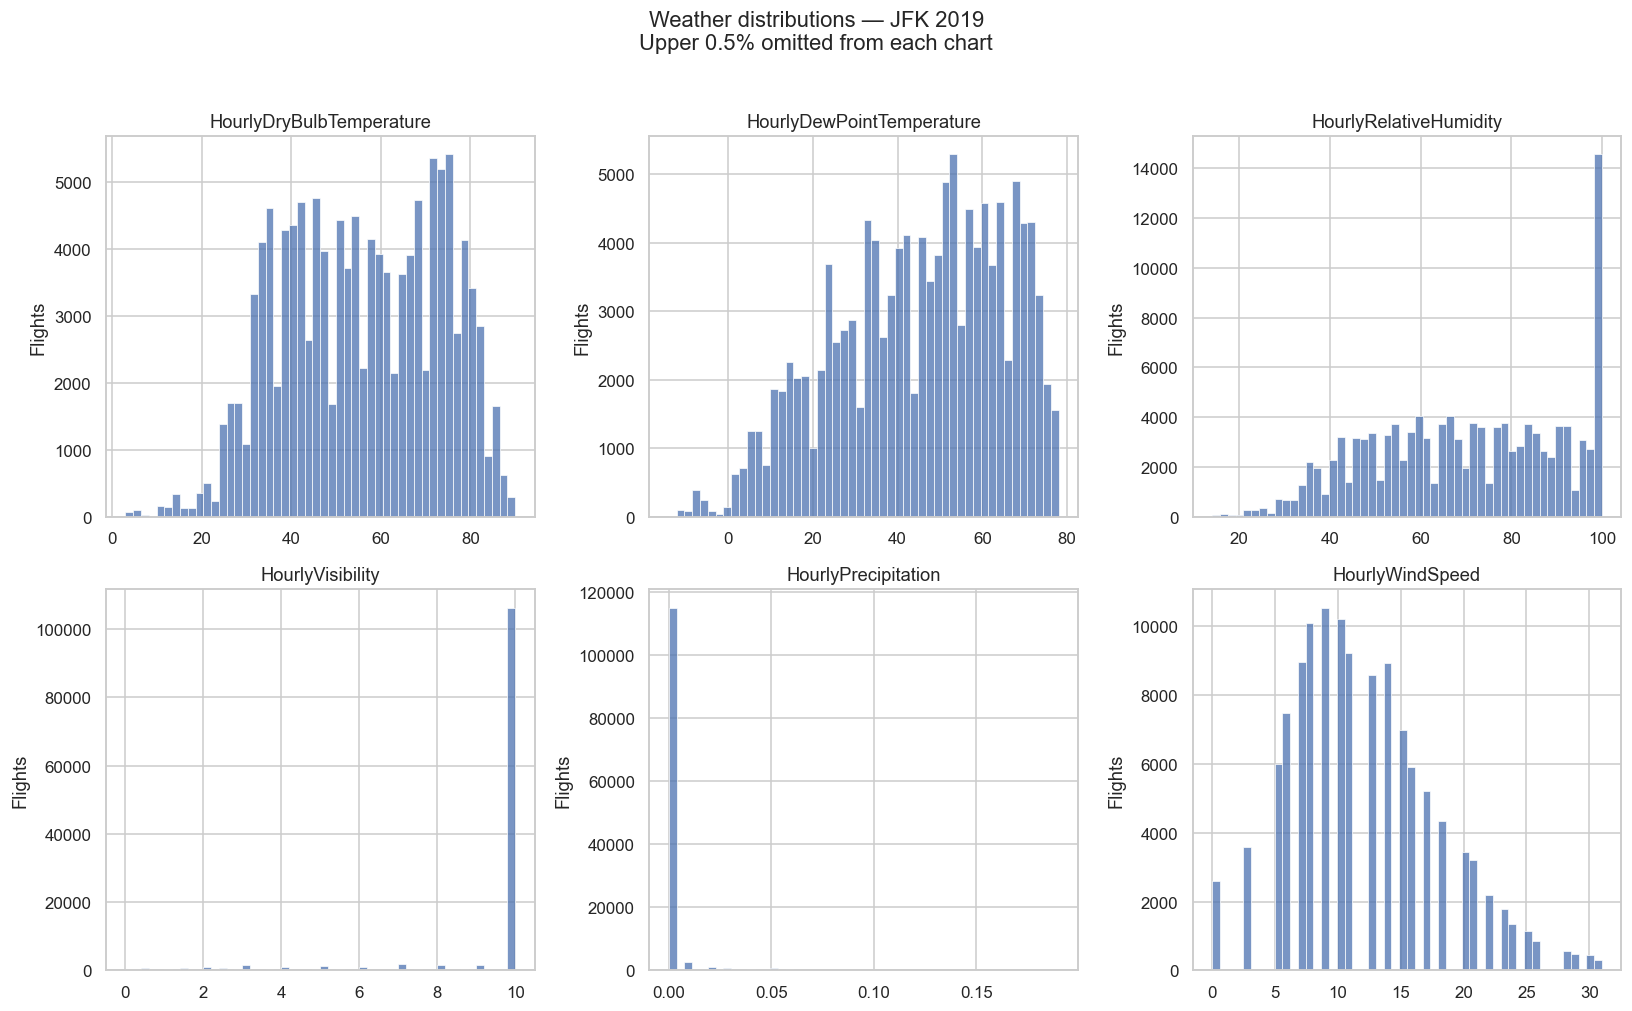

In [2]:
weather_columns = [
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlyPrecipitation",
    "HourlyWindSpeed",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for column, axis in zip(weather_columns, axes.flat):
    upper = df[column].quantile(0.995)
    sns.histplot(df.loc[df[column] <= upper, column], bins=50, ax=axis)
    axis.set_title(column)
    axis.set_xlabel("")
    axis.set_ylabel("Flights")
fig.suptitle(
    f"Weather distributions — {AIRPORT} {YEAR}\n"
    "Upper 0.5% omitted from each chart",
    y=1.02,
)
plt.tight_layout()
plt.show()

## Adverse-weather comparison

The EDA helper `AdverseWeather` is one when any reported rain, drizzle, snow, fog, mist, thunderstorm, freezing precipitation, or showers flag is active. It provides a simple summary; the individual flags remain available for more detailed analysis.

DepDel15       ArrDel15      
                   size  mean     size  mean
AdverseWeather                              
0                108501 0.179   108501 0.181
1                 16258 0.256    16258 0.340

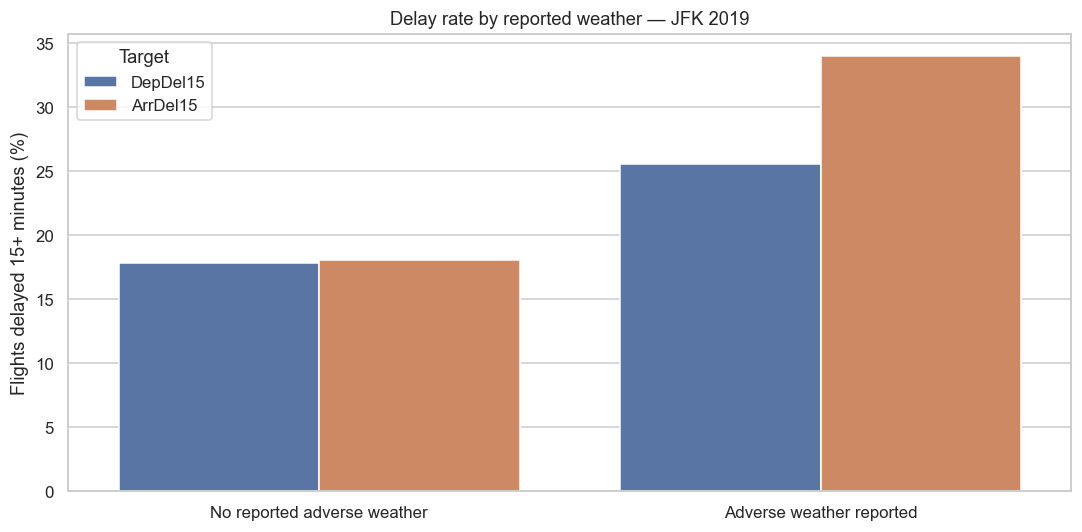

In [3]:
adverse_rates = (
    df.groupby("AdverseWeather")[list(TARGET_COLUMNS)]
    .agg(["size", "mean"])
)
display(adverse_rates)

adverse_plot = (
    df.groupby("AdverseWeather")[list(TARGET_COLUMNS)]
    .mean()
    .mul(100)
    .rename(index={0: "No reported adverse weather", 1: "Adverse weather reported"})
    .reset_index(names="Weather")
    .melt(id_vars="Weather", var_name="Target", value_name="DelayRate")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=adverse_plot, x="Weather", y="DelayRate", hue="Target")
plt.title(f"Delay rate by reported weather — {AIRPORT} {YEAR}")
plt.xlabel("")
plt.ylabel("Flights delayed 15+ minutes (%)")
plt.tight_layout()
plt.show()

## Individual weather conditions

A condition with very few flights can have an unstable delay rate, so the table includes both flight counts and rates.

,Condition,Flights,ShareOfFlights,DepartureDelayRate,ArrivalDelayRate
0,Rain,10608,8.503,25.113,31.806
4,Mist,8020,6.428,25.860,36.135
1,Drizzle,1320,1.058,12.045,16.591
2,Snow,927,0.743,38.511,76.268
3,Fog,756,0.606,32.540,44.444
5,Thunderstorm,621,0.498,58.132,81.481
6,FreezingPrecip,78,0.063,64.103,91.026
7,Showers,0,0.000,NaN,NaN


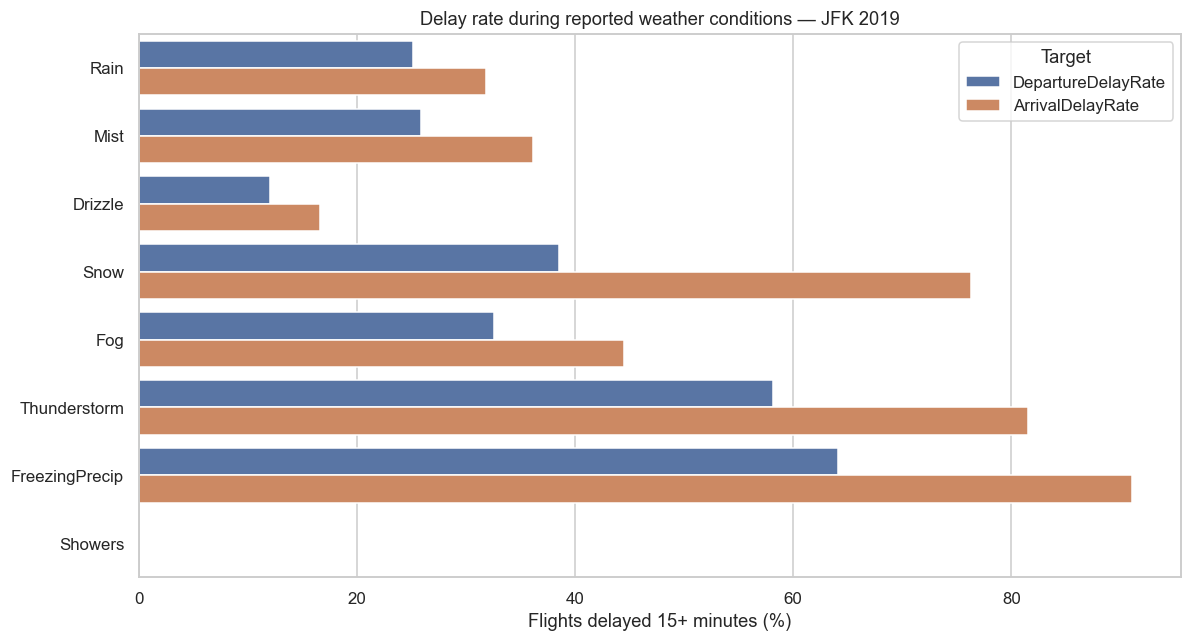

In [4]:
weather_summary = []
for condition in WEATHER_FLAGS:
    if condition not in df:
        continue
    active = df.loc[df[condition] == 1]
    weather_summary.append(
        {
            "Condition": condition,
            "Flights": len(active),
            "ShareOfFlights": len(active) / len(df) * 100,
            "DepartureDelayRate": active["DepDel15"].mean() * 100,
            "ArrivalDelayRate": active["ArrDel15"].mean() * 100,
        }
    )

weather_summary = pd.DataFrame(weather_summary).sort_values("Flights", ascending=False)
display(weather_summary)

weather_long = weather_summary.melt(
    id_vars=["Condition", "Flights", "ShareOfFlights"],
    value_vars=["DepartureDelayRate", "ArrivalDelayRate"],
    var_name="Target",
    value_name="DelayRate",
)

plt.figure(figsize=(11, 6))
sns.barplot(data=weather_long, x="DelayRate", y="Condition", hue="Target")
plt.title(f"Delay rate during reported weather conditions — {AIRPORT} {YEAR}")
plt.xlabel("Flights delayed 15+ minutes (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Visibility

Visibility categories make the relationship easier to read than a dense scatterplot. The categories are EDA aids and do not have to be used as final model features.

DepDel15       ArrDel15      
                       size  mean     size  mean
VisibilityCategory                              
Very low (<2)          3466 0.300     3466 0.466
Low (2–5)              5471 0.222     5471 0.297
Moderate (5–8)         5637 0.253     5637 0.314
Good (8+)            110185 0.180   110185 0.183

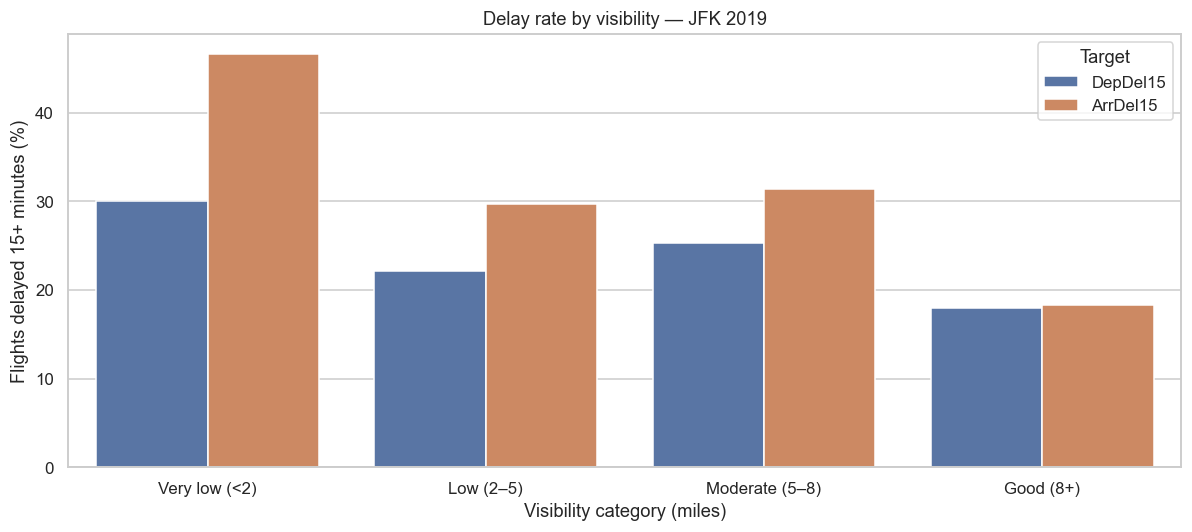

In [5]:
visibility_order = ["Very low (<2)", "Low (2–5)", "Moderate (5–8)", "Good (8+)"]
visibility_rates = (
    df.groupby("VisibilityCategory", observed=True)[list(TARGET_COLUMNS)]
    .agg(["size", "mean"])
)
display(visibility_rates)

visibility_plot = (
    df.groupby("VisibilityCategory", observed=True)[list(TARGET_COLUMNS)]
    .mean()
    .mul(100)
    .reindex(visibility_order)
    .reset_index()
    .melt(id_vars="VisibilityCategory", var_name="Target", value_name="DelayRate")
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=visibility_plot,
    x="VisibilityCategory",
    y="DelayRate",
    hue="Target",
    order=visibility_order,
)
plt.title(f"Delay rate by visibility — {AIRPORT} {YEAR}")
plt.xlabel("Visibility category (miles)")
plt.ylabel("Flights delayed 15+ minutes (%)")
plt.tight_layout()
plt.show()

## Scheduled airport traffic

ASPM scheduled departures and arrivals are combined into a simple total-traffic measure. The distribution shows the airport's typical operating range at the matched ASPM hour.

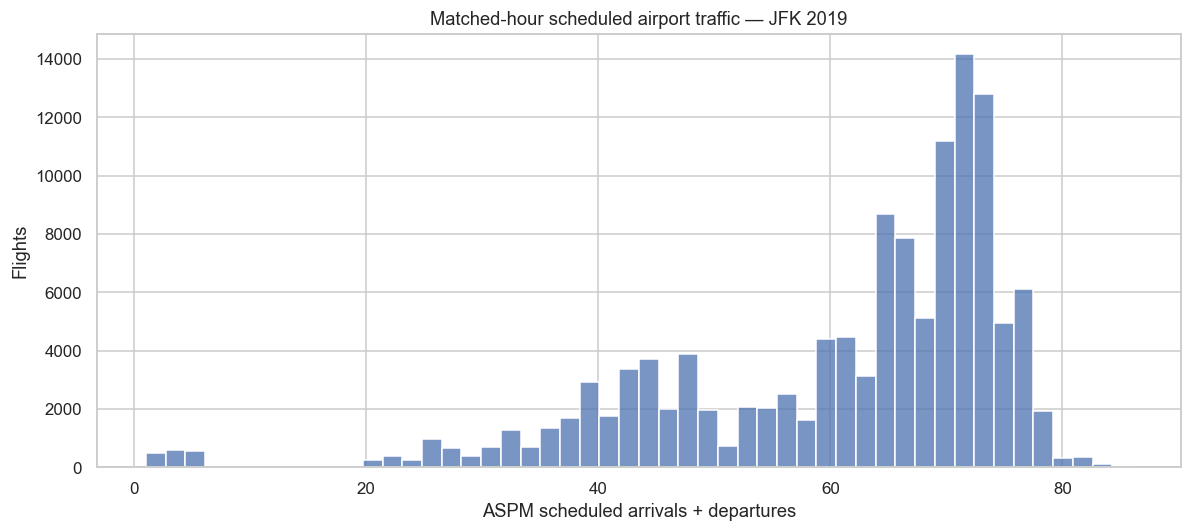

count   124,759.000
mean         60.945
std          14.962
min           1.000
10%          40.000
25%          52.000
50%          66.000
75%          72.000
90%          75.000
99%          79.000
max          86.000
Name: ASPM_Total_Scheduled_Traffic, dtype: float64

In [6]:
plt.figure(figsize=(11, 5))
sns.histplot(df["ASPM_Total_Scheduled_Traffic"], bins=50, color="#4C72B0")
plt.title(f"Matched-hour scheduled airport traffic — {AIRPORT} {YEAR}")
plt.xlabel("ASPM scheduled arrivals + departures")
plt.ylabel("Flights")
plt.tight_layout()
plt.show()

display(df["ASPM_Total_Scheduled_Traffic"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]))

## Delay rate by traffic level

Traffic is divided into five equally sized groups for this descriptive view. The cut points are specific to the selected airport-year and should not be treated as final model thresholds.

DepDel15       ArrDel15      
                  size  mean     size  mean
TrafficGroup                               
(0.999, 47.0]    26454 0.109    26454 0.136
(47.0, 63.0]     24626 0.157    24626 0.172
(63.0, 69.0]     26695 0.172    26695 0.177
(69.0, 73.0]     27031 0.250    27031 0.256
(73.0, 86.0]     19953 0.272    19953 0.284

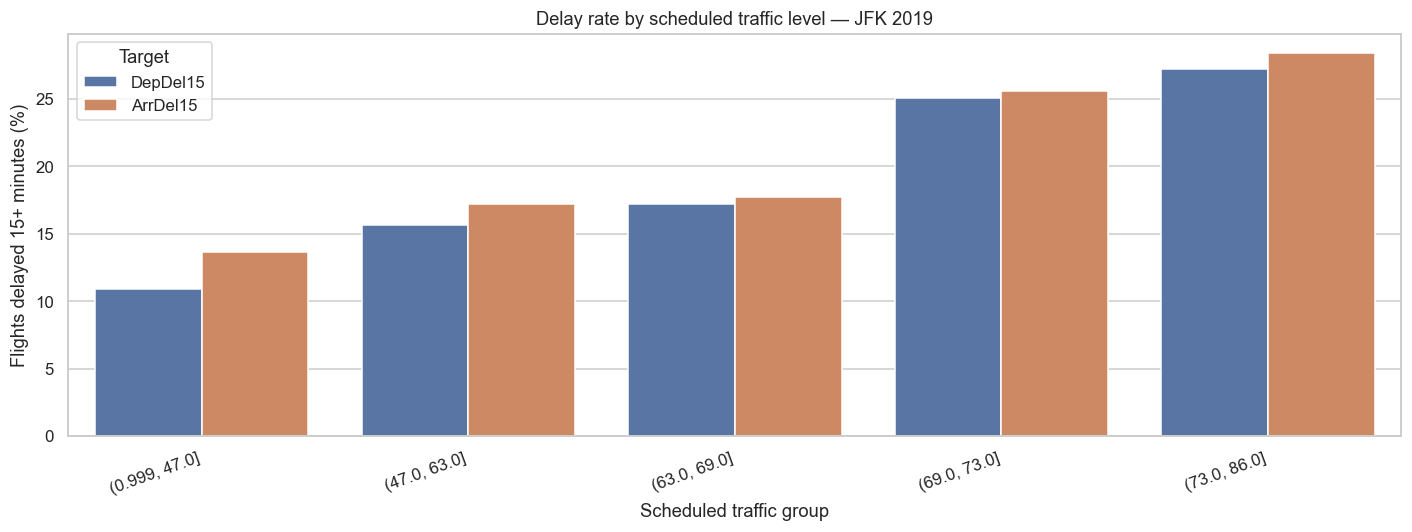

In [7]:
df["TrafficGroup"] = pd.qcut(
    df["ASPM_Total_Scheduled_Traffic"],
    q=5,
    duplicates="drop",
)

traffic_rates = (
    df.groupby("TrafficGroup", observed=True)[list(TARGET_COLUMNS)]
    .agg(["size", "mean"])
)
display(traffic_rates)

traffic_plot = (
    df.groupby("TrafficGroup", observed=True)[list(TARGET_COLUMNS)]
    .mean()
    .mul(100)
    .reset_index()
    .melt(id_vars="TrafficGroup", var_name="Target", value_name="DelayRate")
)
traffic_plot["TrafficGroup"] = traffic_plot["TrafficGroup"].astype(str)

plt.figure(figsize=(13, 5))
sns.barplot(data=traffic_plot, x="TrafficGroup", y="DelayRate", hue="Target")
plt.title(f"Delay rate by scheduled traffic level — {AIRPORT} {YEAR}")
plt.xlabel("Scheduled traffic group")
plt.ylabel("Flights delayed 15+ minutes (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Recent ASPM operating conditions

The boxplots compare recent ASPM delay measures for on-time and delayed flights. A reproducible sample is used to keep the plots responsive. Values are capped at the 99th percentile for display only.

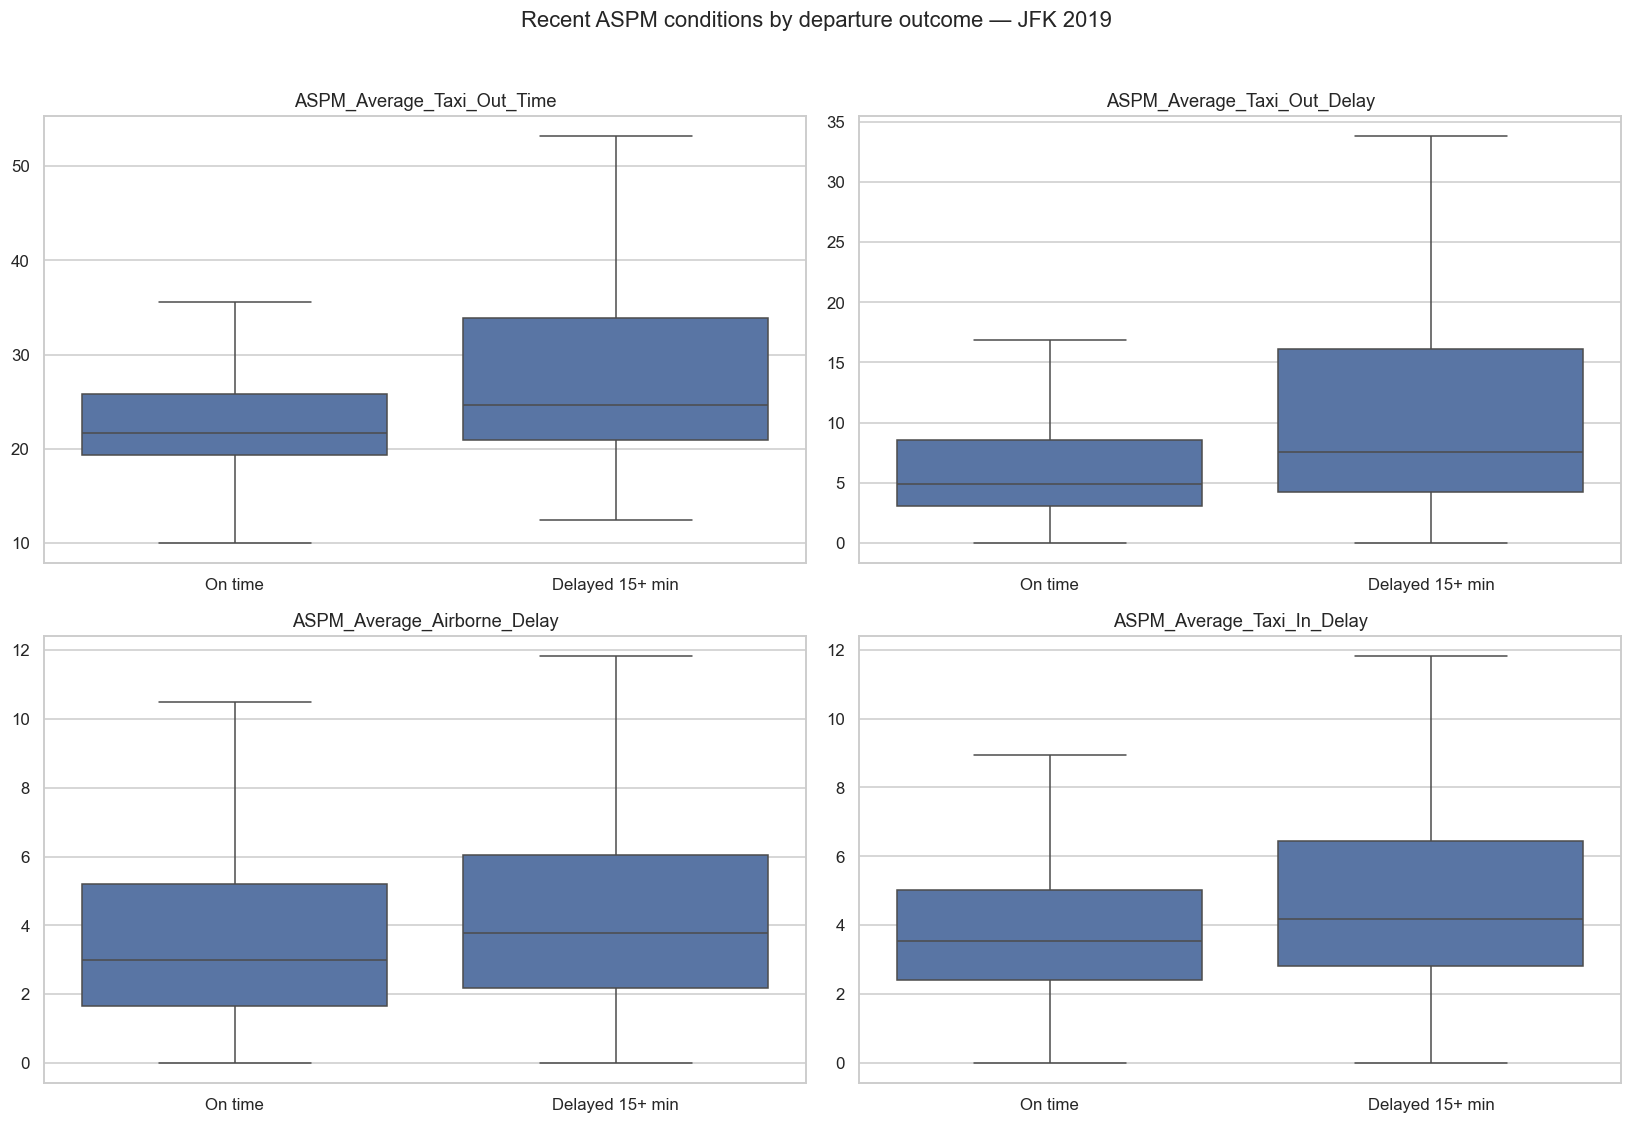

In [8]:
aspm_delay_columns = [
    "ASPM_Average_Taxi_Out_Time",
    "ASPM_Average_Taxi_Out_Delay",
    "ASPM_Average_Airborne_Delay",
    "ASPM_Average_Taxi_In_Delay",
]
plot_sample = safe_sample(df, SCATTER_SAMPLE_SIZE, RANDOM_STATE)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for column, axis in zip(aspm_delay_columns, axes.flat):
    upper = plot_sample[column].quantile(0.99)
    plot_frame = plot_sample.loc[plot_sample[column] <= upper].copy()
    sns.boxplot(
        data=plot_frame,
        x="DepDel15_Label",
        y=column,
        order=["On time", "Delayed 15+ min"],
        showfliers=False,
        ax=axis,
    )
    axis.set_title(column)
    axis.set_xlabel("")
    axis.set_ylabel("")
fig.suptitle(f"Recent ASPM conditions by departure outcome — {AIRPORT} {YEAR}", y=1.02)
plt.tight_layout()
plt.show()

## Weather and congestion together

This heatmap compares departure-delay rates across adverse-weather status and scheduled traffic groups. It helps identify whether busy periods and weather appear more important together than separately.

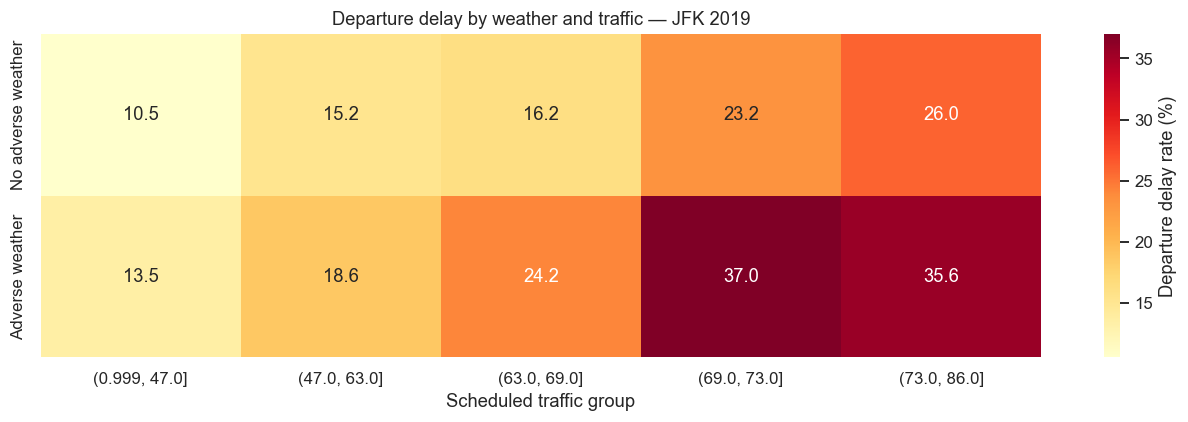

In [9]:
interaction = (
    df.pivot_table(
        index="AdverseWeather",
        columns="TrafficGroup",
        values="DepDel15",
        aggfunc="mean",
        observed=True,
    )
    .mul(100)
    .rename(index={0: "No adverse weather", 1: "Adverse weather"})
)
interaction.columns = interaction.columns.astype(str)

plt.figure(figsize=(12, 4))
sns.heatmap(
    interaction,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={"label": "Departure delay rate (%)"},
)
plt.title(f"Departure delay by weather and traffic — {AIRPORT} {YEAR}")
plt.xlabel("Scheduled traffic group")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Correlation overview

Correlation is shown only for selected numeric weather, congestion, age, and target columns. It is a screening view: weak linear correlation does not mean a feature is useless, and strong correlation does not establish cause.

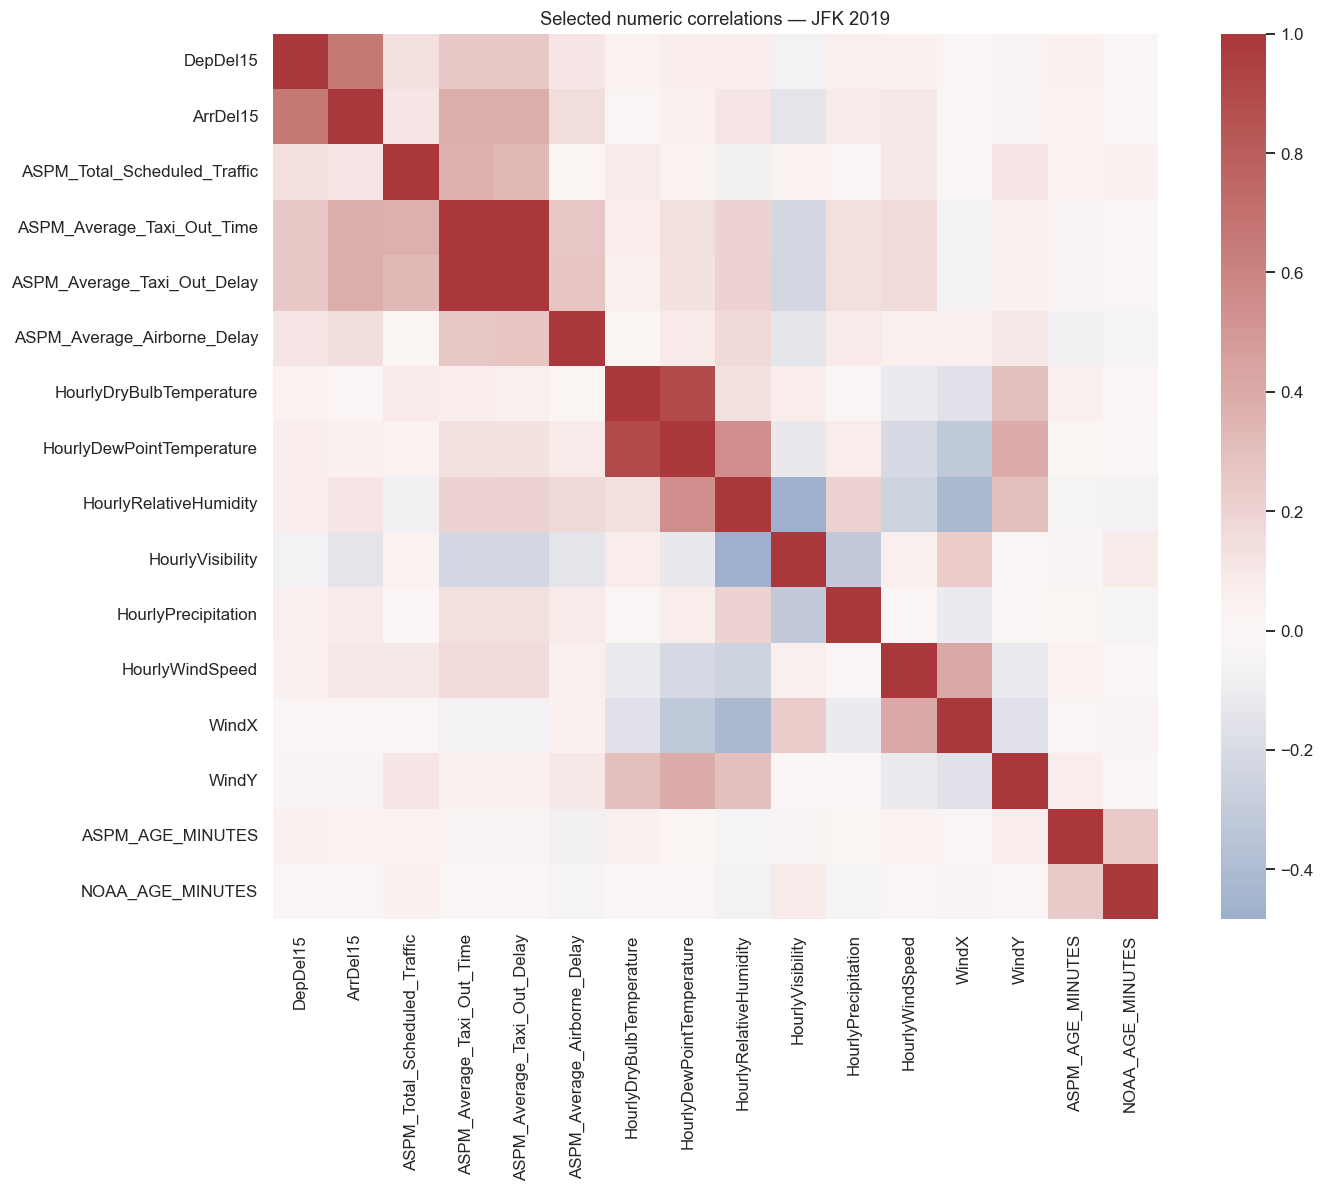

In [10]:
correlation_columns = [
    "DepDel15",
    "ArrDel15",
    "ASPM_Total_Scheduled_Traffic",
    "ASPM_Average_Taxi_Out_Time",
    "ASPM_Average_Taxi_Out_Delay",
    "ASPM_Average_Airborne_Delay",
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlyPrecipitation",
    "HourlyWindSpeed",
    "WindX",
    "WindY",
    "ASPM_AGE_MINUTES",
    "NOAA_AGE_MINUTES",
]
correlations = df[correlation_columns].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(correlations, cmap="vlag", center=0, square=True)
plt.title(f"Selected numeric correlations — {AIRPORT} {YEAR}")
plt.tight_layout()
plt.show()

## Interpretation guide

Use these charts to identify patterns worth checking across all airports and years. Weather and airport conditions often occur together, so a simple two-variable chart cannot separate their effects. The later models and explanation tools will provide a more controlled comparison.